# CVE to CWE Mapping

## Pre reqs:
You need to have ran scrape_cwe.ipynb file and fill the CVE folder in scrapers/scraped_data in order to continue

### Requirements

In [ ]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu 
%pip install sentence-transformers pandas tqdm matplotlib

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
from sentence_transformers import SentenceTransformer, CrossEncoder
from sentence_transformers.util import semantic_search, dot_score
import torch
import numpy as np
import json
import pandas as pd
from tqdm import tqdm
from functools import lru_cache
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

## Loading scraped data

In [2]:
!git clone https://github.com/regularpooria/CWE_CVE_Mapping # Kaggle
BASE_DIR = "./CWE_CVE_Mapping" # Kaggle
# BASE_DIR = "../" # Local

fatal: destination path 'CWE_CVE_Mapping' already exists and is not an empty directory.


### Loading CWE

In [3]:
with open(f"{BASE_DIR}/scrapers/scraped_data/CWE_SOFTWARE.json", "r", encoding="utf-8") as f:
    CWE = json.load(f)

### Loading CVE

In [4]:
CVE_files = ["nvd_2025_cwe699.csv"]

CVE: pd.DataFrame = pd.DataFrame()
for i, file in enumerate(CVE_files):
    if i == 0:
        CVE = pd.read_csv(f"{BASE_DIR}/scrapers/scraped_data/CVE/{file}")
        continue
    
    CVE = pd.concat([CVE, pd.read_csv(f"{BASE_DIR}/scrapers/scraped_data/CVE/{file}")], ignore_index=True)

## Embedding

In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained("mulliken/cwe-predictor").to(device)
tokenizer = AutoTokenizer.from_pretrained("mulliken/cwe-predictor")
model.eval()

# Prediction function
def predict_cwe(text: str) -> str:
    encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        logits = model(**encoded).logits
        pred_id = torch.argmax(logits, dim=-1).item()
    return model.config.id2label[pred_id]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

In [6]:
predict_cwe("A security flaw has been discovered in itsourcecode School Management System 1.0. This affects an unknown part of the file /student/index.php. The manipulation of the argument ID results in sql injection. It is possible to launch the attack remotely. The exploit has been released to the public and may be used for attacks.")

'CWE-89'

In [7]:
# Checking for embeding description values
if len(CVE[CVE["description"].notna() == False]) != 0:
    raise ValueError("Some descriptions in CVE are empty, please check and remove")

## Predicting CWE category

In [11]:
@lru_cache
def find_category_from_children(child):
    child = child.split("-")[-1]
    for category_id, category in CWE.items():
        if child in list(category["children"].keys()):
            return category_id
    return None
    # raise ValueError(f"Could not find category for child: {child}")
CVE["cwe_699_category"] = CVE["cwe_699_matches"].apply(find_category_from_children)

In [9]:
tqdm.pandas()
CVE["cwe_699_child_prediction"] = CVE["description"].progress_apply(predict_cwe)

100%|██████████| 26816/26816 [02:13<00:00, 200.67it/s]


In [12]:
CVE["cwe_699_category_prediction"] = CVE["cwe_699_child_prediction"].apply(find_category_from_children)

In [13]:
CVE.head(5)

,cve_id,published,last_modified,published_year,description,all_nvd_cwes,cwe_699_matches,number_of_nvd_cwes,number_of_cwe_699_matches,cwe_699_category,cwe_699_child_prediction,cwe_699_category_prediction
0,CVE-2025-0168,2025-01-01T14:15:23.590,2026-06-17T08:26:00.070,2025,A vulnerability classified as critical has bee...,CWE-74|CWE-89,CWE-89,2,1,137,CWE-89,137
1,CVE-2025-22214,2025-01-02T04:15:06.277,2026-06-17T08:45:38.530,2025,Landray EIS 2001 through 2006 allows Message/f...,CWE-89,CWE-89,1,1,137,CWE-89,137
2,CVE-2025-0171,2025-01-02T15:15:25.550,2026-06-17T08:26:00.413,2025,"A vulnerability, which was classified as criti...",CWE-74|CWE-89,CWE-89,2,1,137,CWE-89,137
3,CVE-2025-0172,2025-01-02T16:15:09.103,2026-06-17T08:26:00.560,2025,A vulnerability has been found in code-project...,CWE-74|CWE-89,CWE-89,2,1,137,CWE-89,137
4,CVE-2025-0173,2025-01-02T18:15:21.630,2026-06-17T08:26:00.697,2025,A vulnerability was found in SourceCodester On...,CWE-74|CWE-89,CWE-89,2,1,137,CWE-89,137


Overall DistilBERT baseline accuracy: 0.697
Overall child-level (CWE) accuracy: 0.681


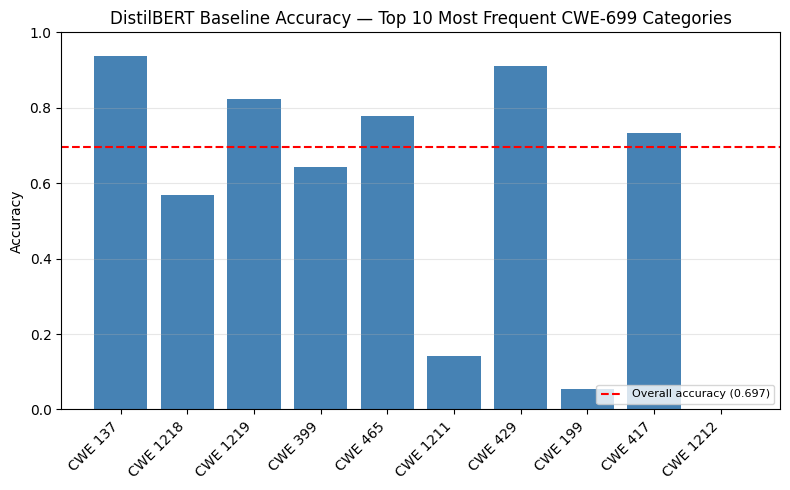

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- overall accuracy ---
overall_accuracy = np.mean(CVE["cwe_699_category"] == CVE["cwe_699_category_prediction"])
print(f"Overall DistilBERT baseline accuracy: {overall_accuracy:.3f}")

# --- child-level accuracy: does the predicted CWE appear in the true cwe_699_matches? ---
def is_child_correct(pred, true_matches_str):
    true_children = true_matches_str.split("|")
    return pred in true_children

CVE["child_prediction_correct"] = [
    is_child_correct(pred, true_str)
    for pred, true_str in zip(CVE["cwe_699_child_prediction"], CVE["cwe_699_matches"])
]

overall_child_accuracy = CVE["child_prediction_correct"].mean()
print(f"Overall child-level (CWE) accuracy: {overall_child_accuracy:.3f}")
# --- per-category accuracy, for top 10 most frequent categories ---
top_n_categories = (
    CVE["cwe_699_category"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

per_cat_accuracy = []
for cat in top_n_categories:
    subset = CVE[CVE["cwe_699_category"] == cat]
    acc = np.mean(subset["cwe_699_category"] == subset["cwe_699_category_prediction"])
    per_cat_accuracy.append(acc)

# --- plot ---
plt.figure(figsize=(8, 5))
bars = plt.bar([f"CWE {c}" for c in top_n_categories], per_cat_accuracy, color="steelblue")
plt.axhline(overall_accuracy, color="red", linestyle="--", label=f"Overall accuracy ({overall_accuracy:.3f})")

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.title("DistilBERT Baseline Accuracy — Top 10 Most Frequent CWE-699 Categories")
plt.legend(loc="lower right", fontsize=8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()